<a href="https://colab.research.google.com/github/Perlangas28/Simulacion_1/blob/main/Prueba_Kolgomorov_Smirnov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Prueba de Kolgomorov-Smirnov.

**Alumna: Perla Blancas Hernández**  
**Materia:** Simulación 1
**Prueba aplicada:** Prueba de Kolgomorov-Smirnov.  

El objetivo de este programa es verificar si una muestra de 100 números aleatorios proviene de una distribución Uniforme U(0,1) utilizando la prueba de Kolmogorov–Smirnov.

Se consideran las hipótesis:

H₀: Xi ~ U(0,1)  
H₁: Xi no ~ U(0,1)

La función de distribución teórica para U(0,1) es:

F(x) = x

La prueba compara la función de distribución acumulada empírica Fₙ(x) con la función teórica F(x).

In [2]:
import numpy as np
import pandas as pd

# Datos

datos = [
0.78961, 0.05230, 0.10699, 0.55877, 0.14151,
0.76086, 0.12079, 0.27738, 0.65726, 0.79269,
0.80548, 0.82654, 0.29453, 0.20852, 0.42989,
0.58518, 0.98611, 0.34488, 0.34358, 0.11537,
0.89898, 0.57880, 0.67621, 0.05010, 0.00121,
0.28269, 0.73059, 0.70119, 0.18284, 0.49962,
0.38618, 0.76910, 0.68334, 0.55170, 0.10850,
0.79882, 0.45679, 0.21631, 0.87616, 0.55743,
0.58962, 0.33216, 0.03185, 0.61168, 0.09264,
0.69623, 0.17028, 0.05475, 0.91512, 0.76262,
0.29931, 0.30861, 0.83358, 0.51781, 0.03272,
0.57410, 0.26593, 0.85903, 0.43308, 0.35286,
0.24000, 0.65559, 0.38507, 0.90829, 0.94187,
0.93655, 0.88809, 0.81772, 0.36982, 0.19904,
0.54325, 0.62400, 0.09133, 0.41678, 0.33954,
0.58244, 0.85853, 0.86752, 0.38729, 0.15506,
0.23949, 0.53559, 0.33381, 0.49883, 0.75103,
0.19962, 0.65002, 0.74579, 0.79113, 0.63453,
0.19147, 0.40644, 0.08128, 0.73435, 0.22724,
0.22287, 0.07281, 0.64183, 0.44267, 0.72102
]


El primer paso de la prueba es ordenar los números de la muestra en orden ascendente.

X(1) ≤ X(2) ≤ ... ≤ X(n)

In [3]:
datos_ordenados = np.sort(datos)
n = len(datos_ordenados)

El segundo paso es calcular el estadístico de prueba D:

D⁺ = max [ (i/n) − Xi ]  
D⁻ = max [ Xi − (i−1)/n

In [4]:
i = np.arange(1, n+1)

i_n = i / n
i_1_n = (i-1) / n

D_mas = i_n - datos_ordenados
D_menos = datos_ordenados - i_1_n

D_plus = np.max(D_mas)
D_minus = np.max(D_menos)
D = max(D_plus, D_minus)

Finalmente comparamos con el valor crítico:
D = max(D⁺, D⁻)

In [8]:
tabla = pd.DataFrame({
    "i": i,
    "Xi": datos_ordenados,
    "(i-1)/n": i_1_n,
    "i/n": i_n,
    "D- = Xi - (i-1)/n": D_menos,
    "D+ = i/n - Xi": D_mas
})

print("Tamaño de muestra n =", n)
print("D+ =", D_plus)
print("D- =", D_minus)
print("Estadístico D =", D)
tabla

Tamaño de muestra n = 100
D+ = 0.056420000000000026
D- = 0.02185
Estadístico D = 0.056420000000000026


,i,Xi,(i-1)/n,i/n,D- = Xi - (i-1)/n,D+ = i/n - Xi
0,1,0.00121,0.00,0.01,0.00121,0.00879
1,2,0.03185,0.01,0.02,0.02185,-0.01185
2,3,0.03272,0.02,0.03,0.01272,-0.00272
3,4,0.05010,0.03,0.04,0.02010,-0.01010
4,5,0.05230,0.04,0.05,0.01230,-0.00230
...,...,...,...,...,...,...
95,96,0.90829,0.95,0.96,-0.04171,0.05171
96,97,0.91512,0.96,0.97,-0.04488,0.05488
97,98,0.93655,0.97,0.98,-0.03345,0.04345
98,99,0.94187,0.98,0.99,-0.03813,0.04813


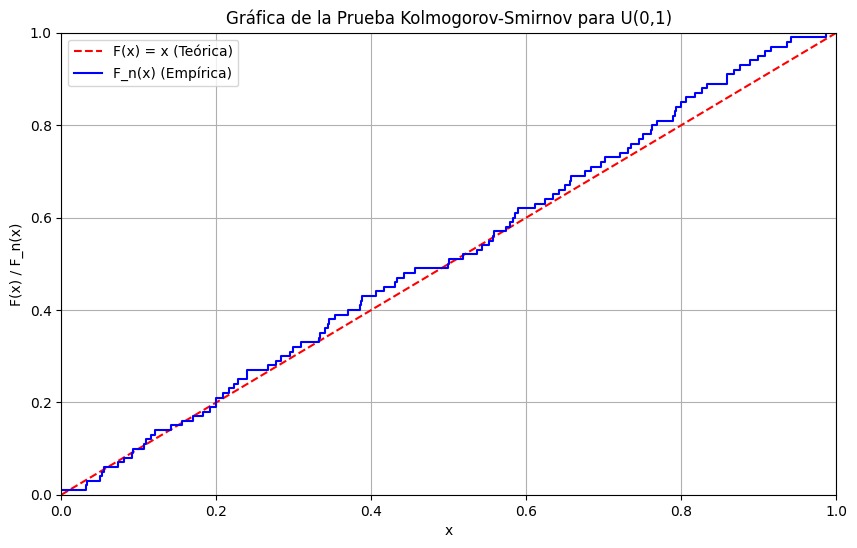

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

plt.plot([0, 1], [0, 1], label='F(x) = x (Teórica)', color='red', linestyle='--')

plt.step(datos_ordenados, i_n, label='F_n(x) (Empírica)', where='post', color='blue')

plt.title('Gráfica de la Prueba Kolmogorov-Smirnov para U(0,1)')
plt.xlabel('x')
plt.ylabel('F(x) / F_n(x)')
plt.legend()
plt.grid(True)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()